### Creating graphs 

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [2]:
conversion = pd.read_json("./conversion.json")
conversion["conversion"] = conversion["conversion"].round(0)
conversion_and_ads = pd.read_json("./conversion_and_ads.json")

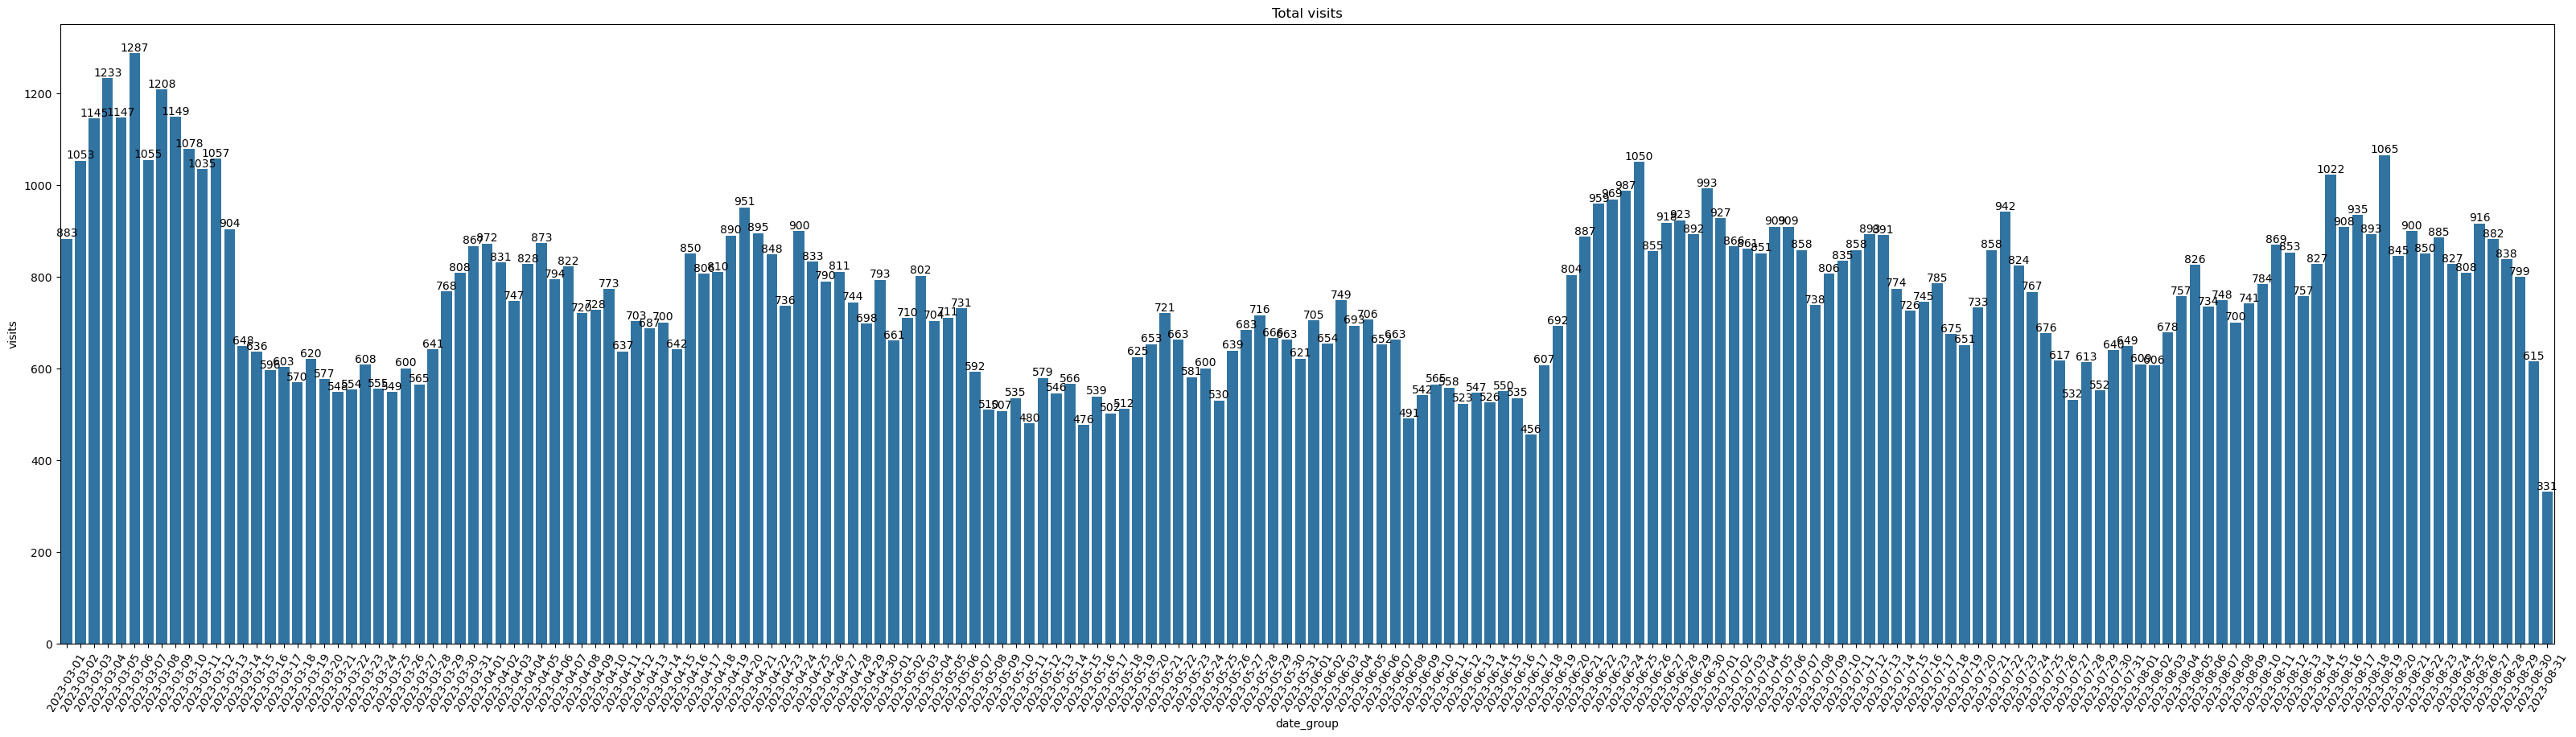

In [17]:
fig, ax = plt.subplots(figsize=(40, 10))
sns.barplot(x="date_group", y="visits", data=conversion_and_ads).set(title="Total visits")
for container in ax.containers:
    ax.bar_label(container)
ax.xaxis.set_tick_params(rotation=60)

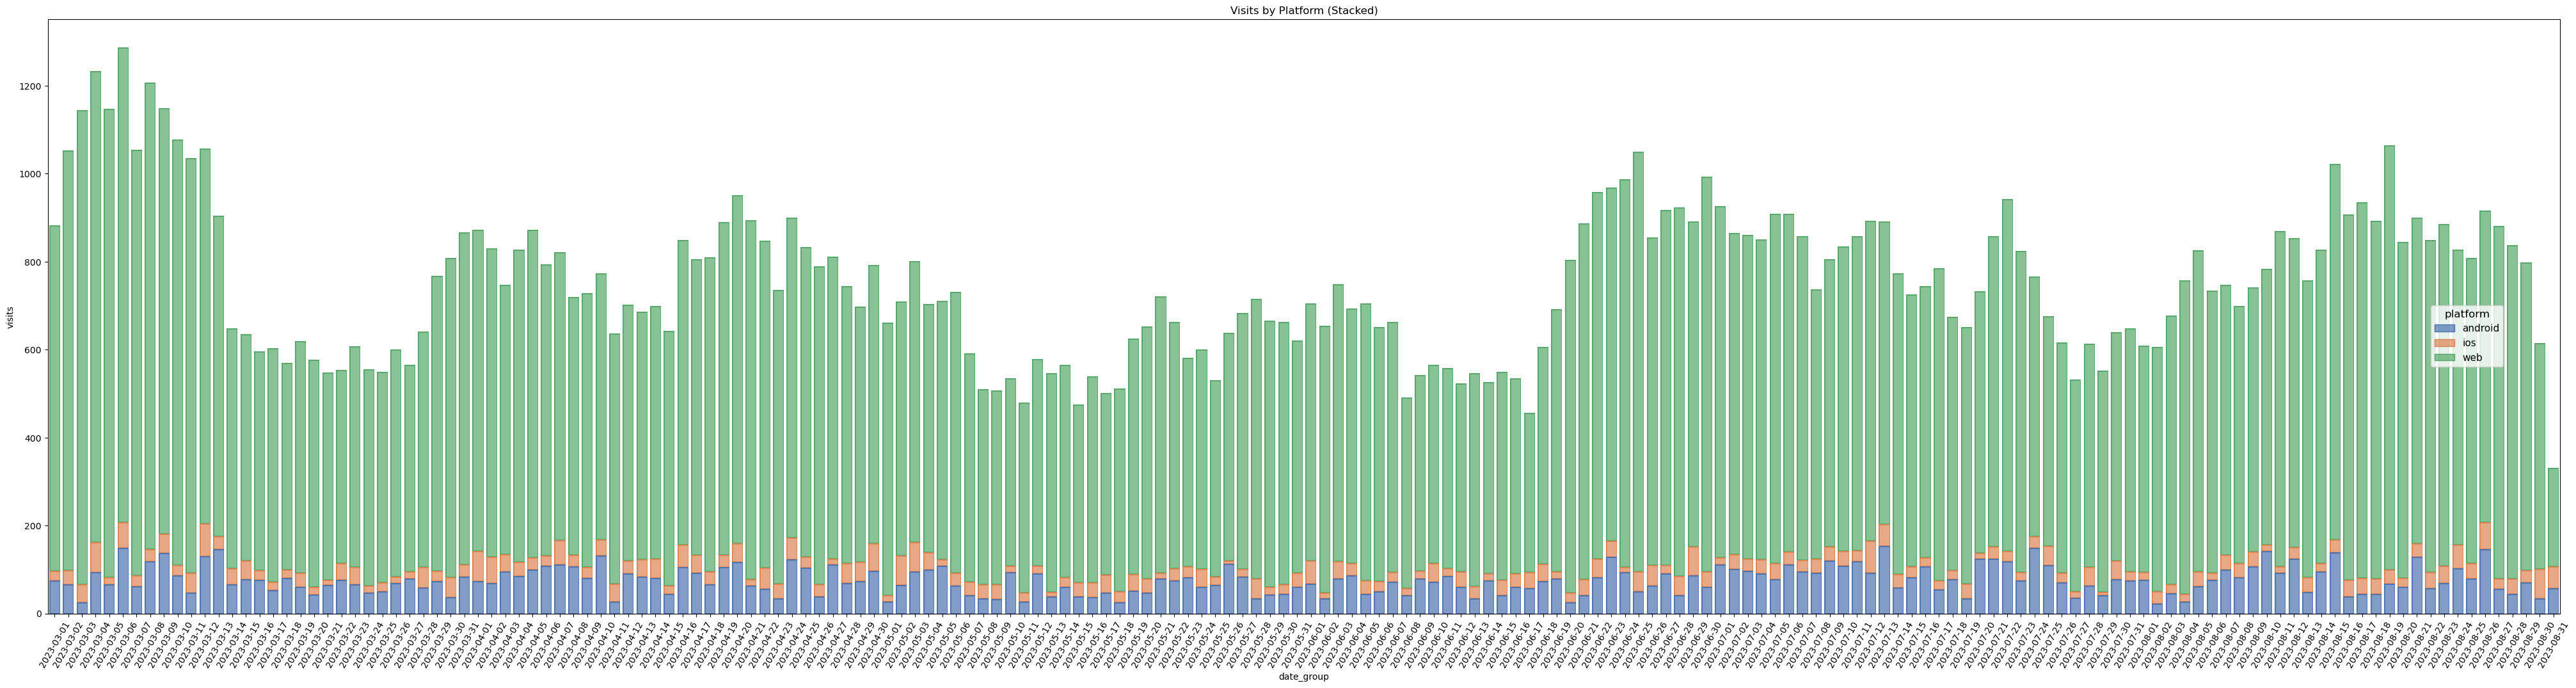

In [197]:
f, ax = plt.subplots(figsize= (40,10))
ax.xaxis.set_tick_params(rotation=60)
plt.tight_layout()
p = (
    so.Plot(conversion, x="date_group", y="visits", color="platform")
    .add(so.Bar(), so.Agg(func="sum"), so.Stack())
    .label(title="Visits by Platform (Stacked)")
    .theme({"grid.color": "black", "axes.facecolor": "white"})
    .on(ax)
)
p.on(ax).show()

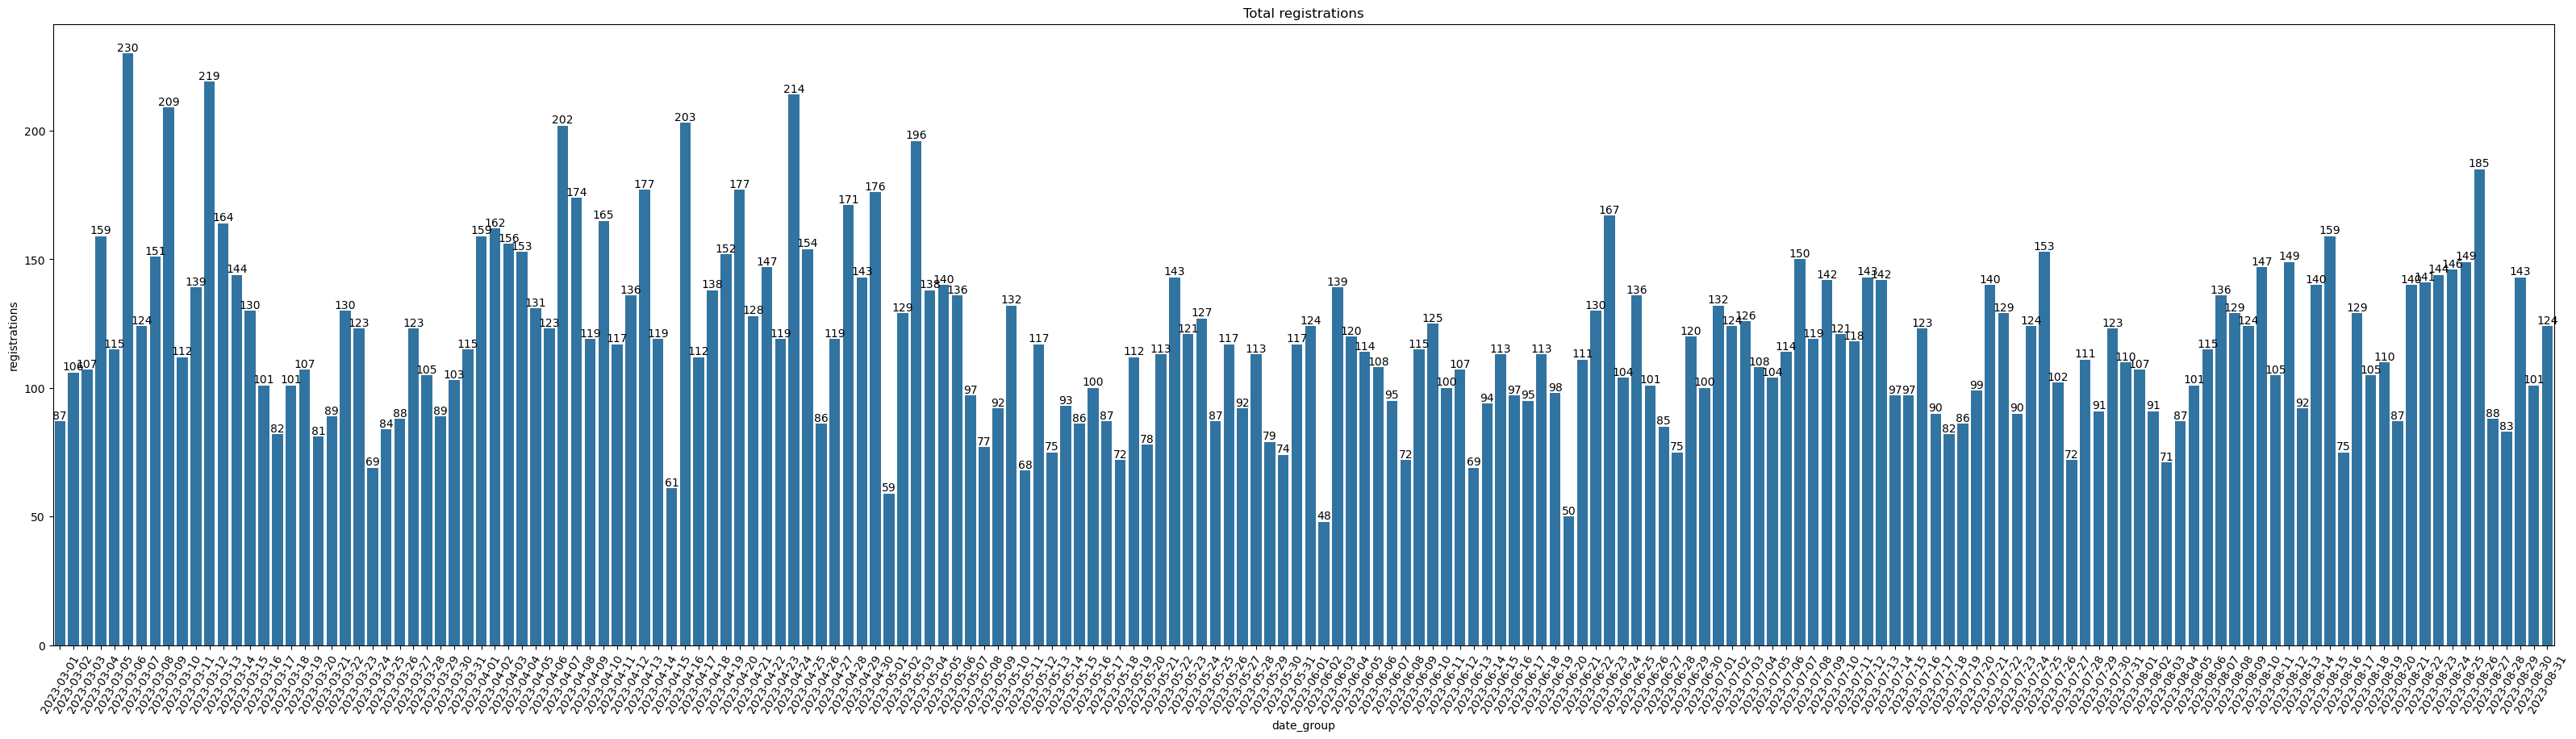

In [146]:
fig, ax = plt.subplots(figsize=(40, 10))
sns.barplot(x="date_group", y="registrations", data=conversion_and_ads).set(title="Total registrations")
for container in ax.containers:
    ax.bar_label(container)
ax.xaxis.set_tick_params(rotation=60)


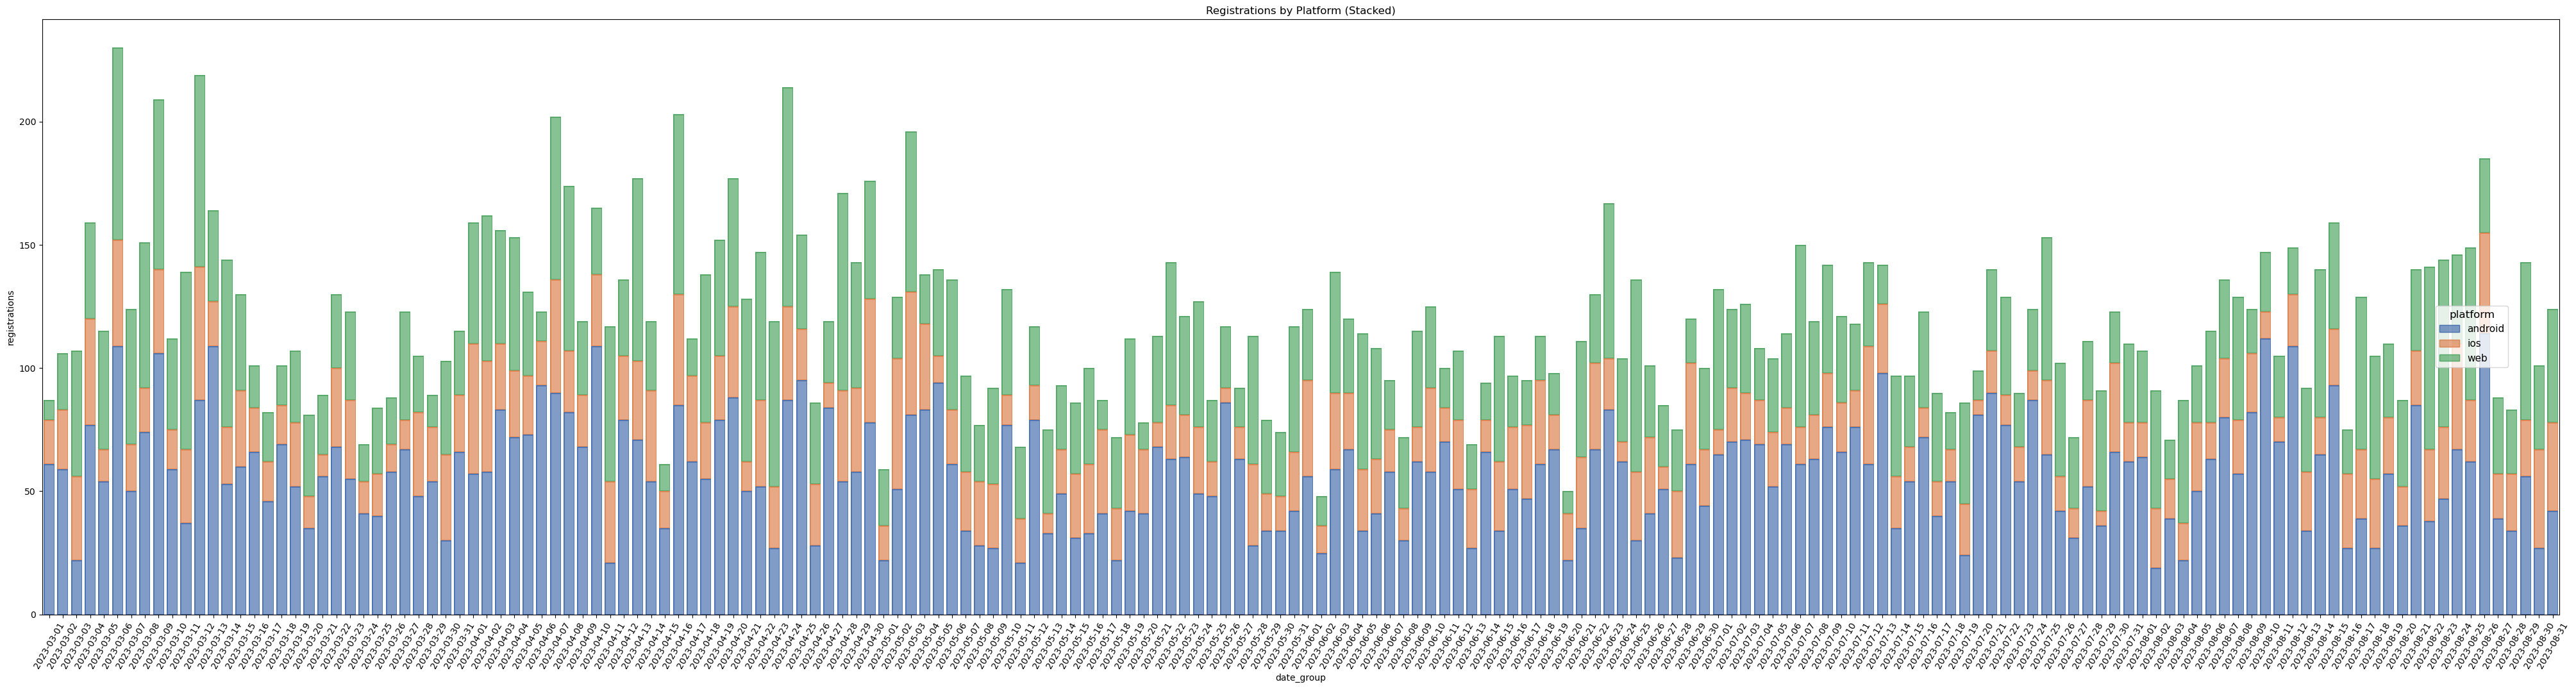

In [196]:
f, ax = plt.subplots(figsize= (40,10))
ax.xaxis.set_tick_params(rotation=60)
plt.tight_layout()
p = (
    so.Plot(conversion, x="date_group", y="registrations", color="platform")
    .add(so.Bar(), so.Agg(func="sum"), so.Stack())
    .label(title="Registrations by Platform (Stacked)")
    .theme({"grid.color": "black", "axes.facecolor": "white"})
)
p.on(ax).show()

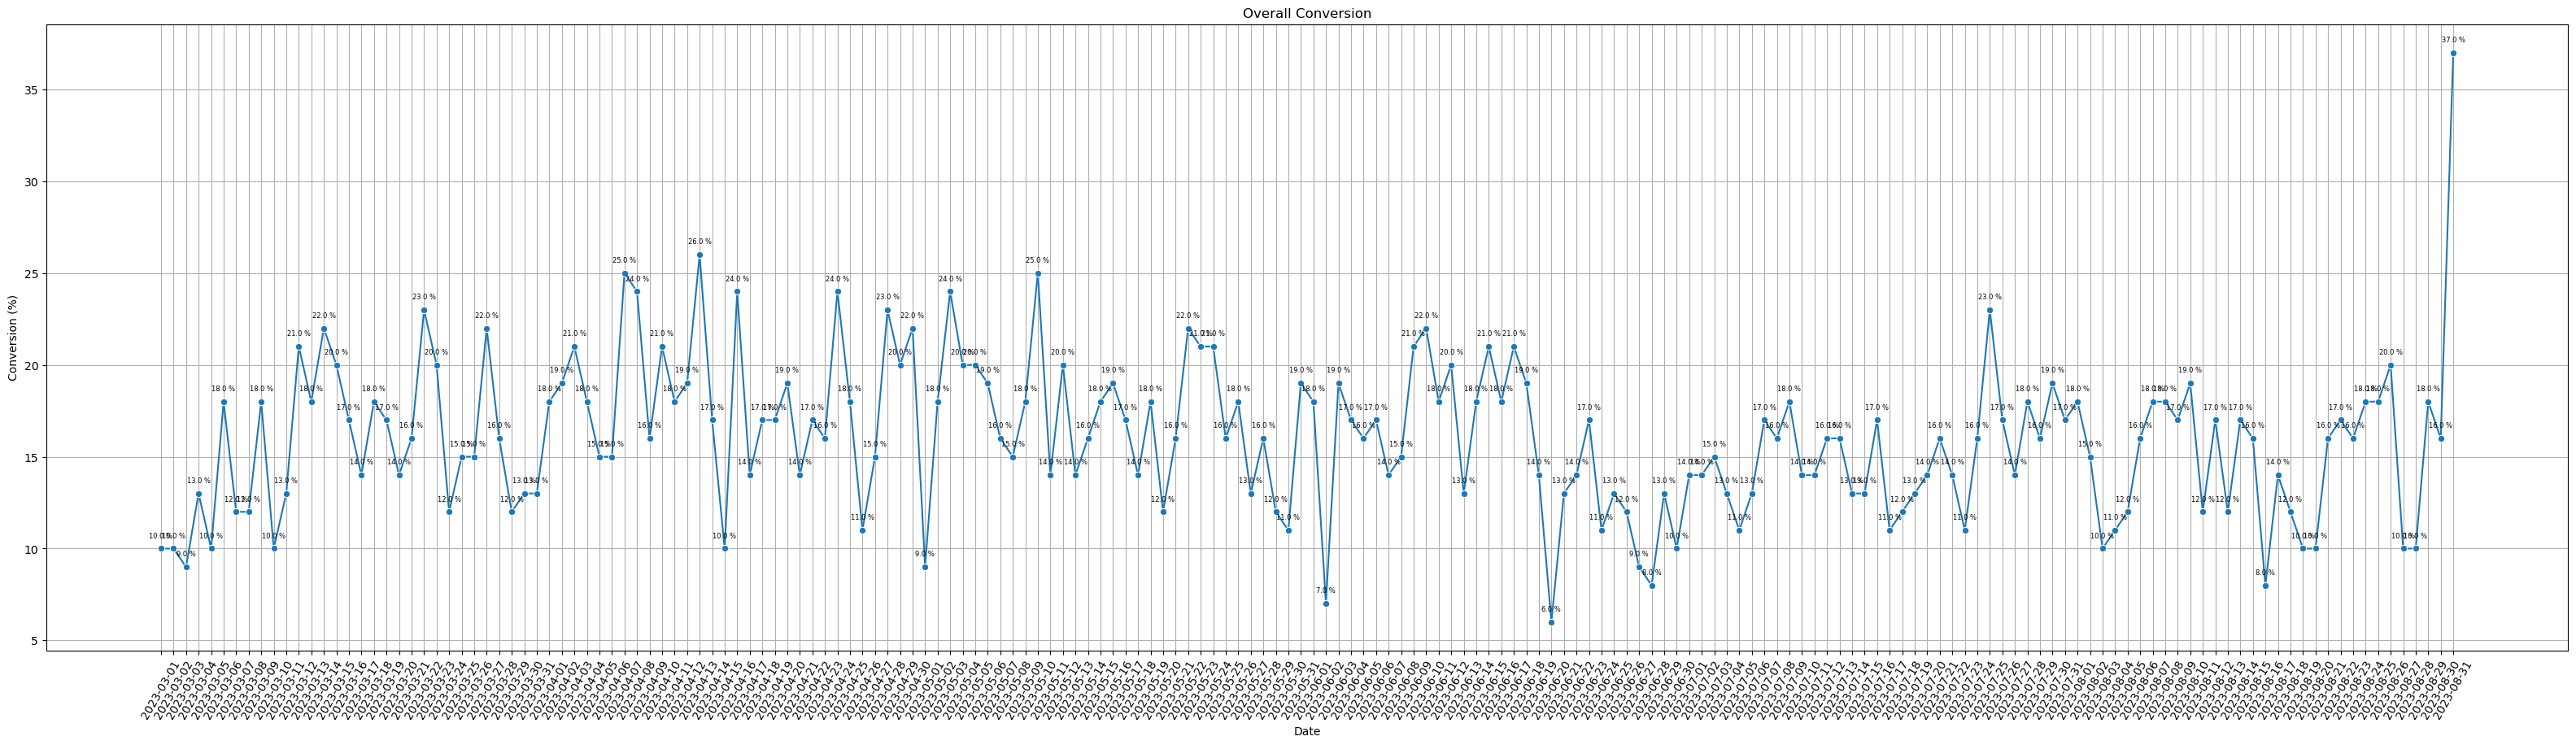

In [204]:
all_platforms = conversion.drop("platform", axis=1).groupby("date_group", as_index=False).agg("sum")
all_platforms["conversion"] = (all_platforms["registrations"]/all_platforms["visits"] * 100).round(0)
fig, ax = plt.subplots(figsize=(40, 10))
sns.lineplot(data=all_platforms, x="date_group", y="conversion", marker="o").set(title="Overall Conversion", xlabel="Date", ylabel="Conversion (%)")
ax.xaxis.set_tick_params(rotation=60)
plt.grid()
for x, y in zip(all_platforms["date_group"], all_platforms["conversion"]):
    ax.text(x, y + 0.5, f'{y} %', ha='center', va='bottom', fontsize=6)

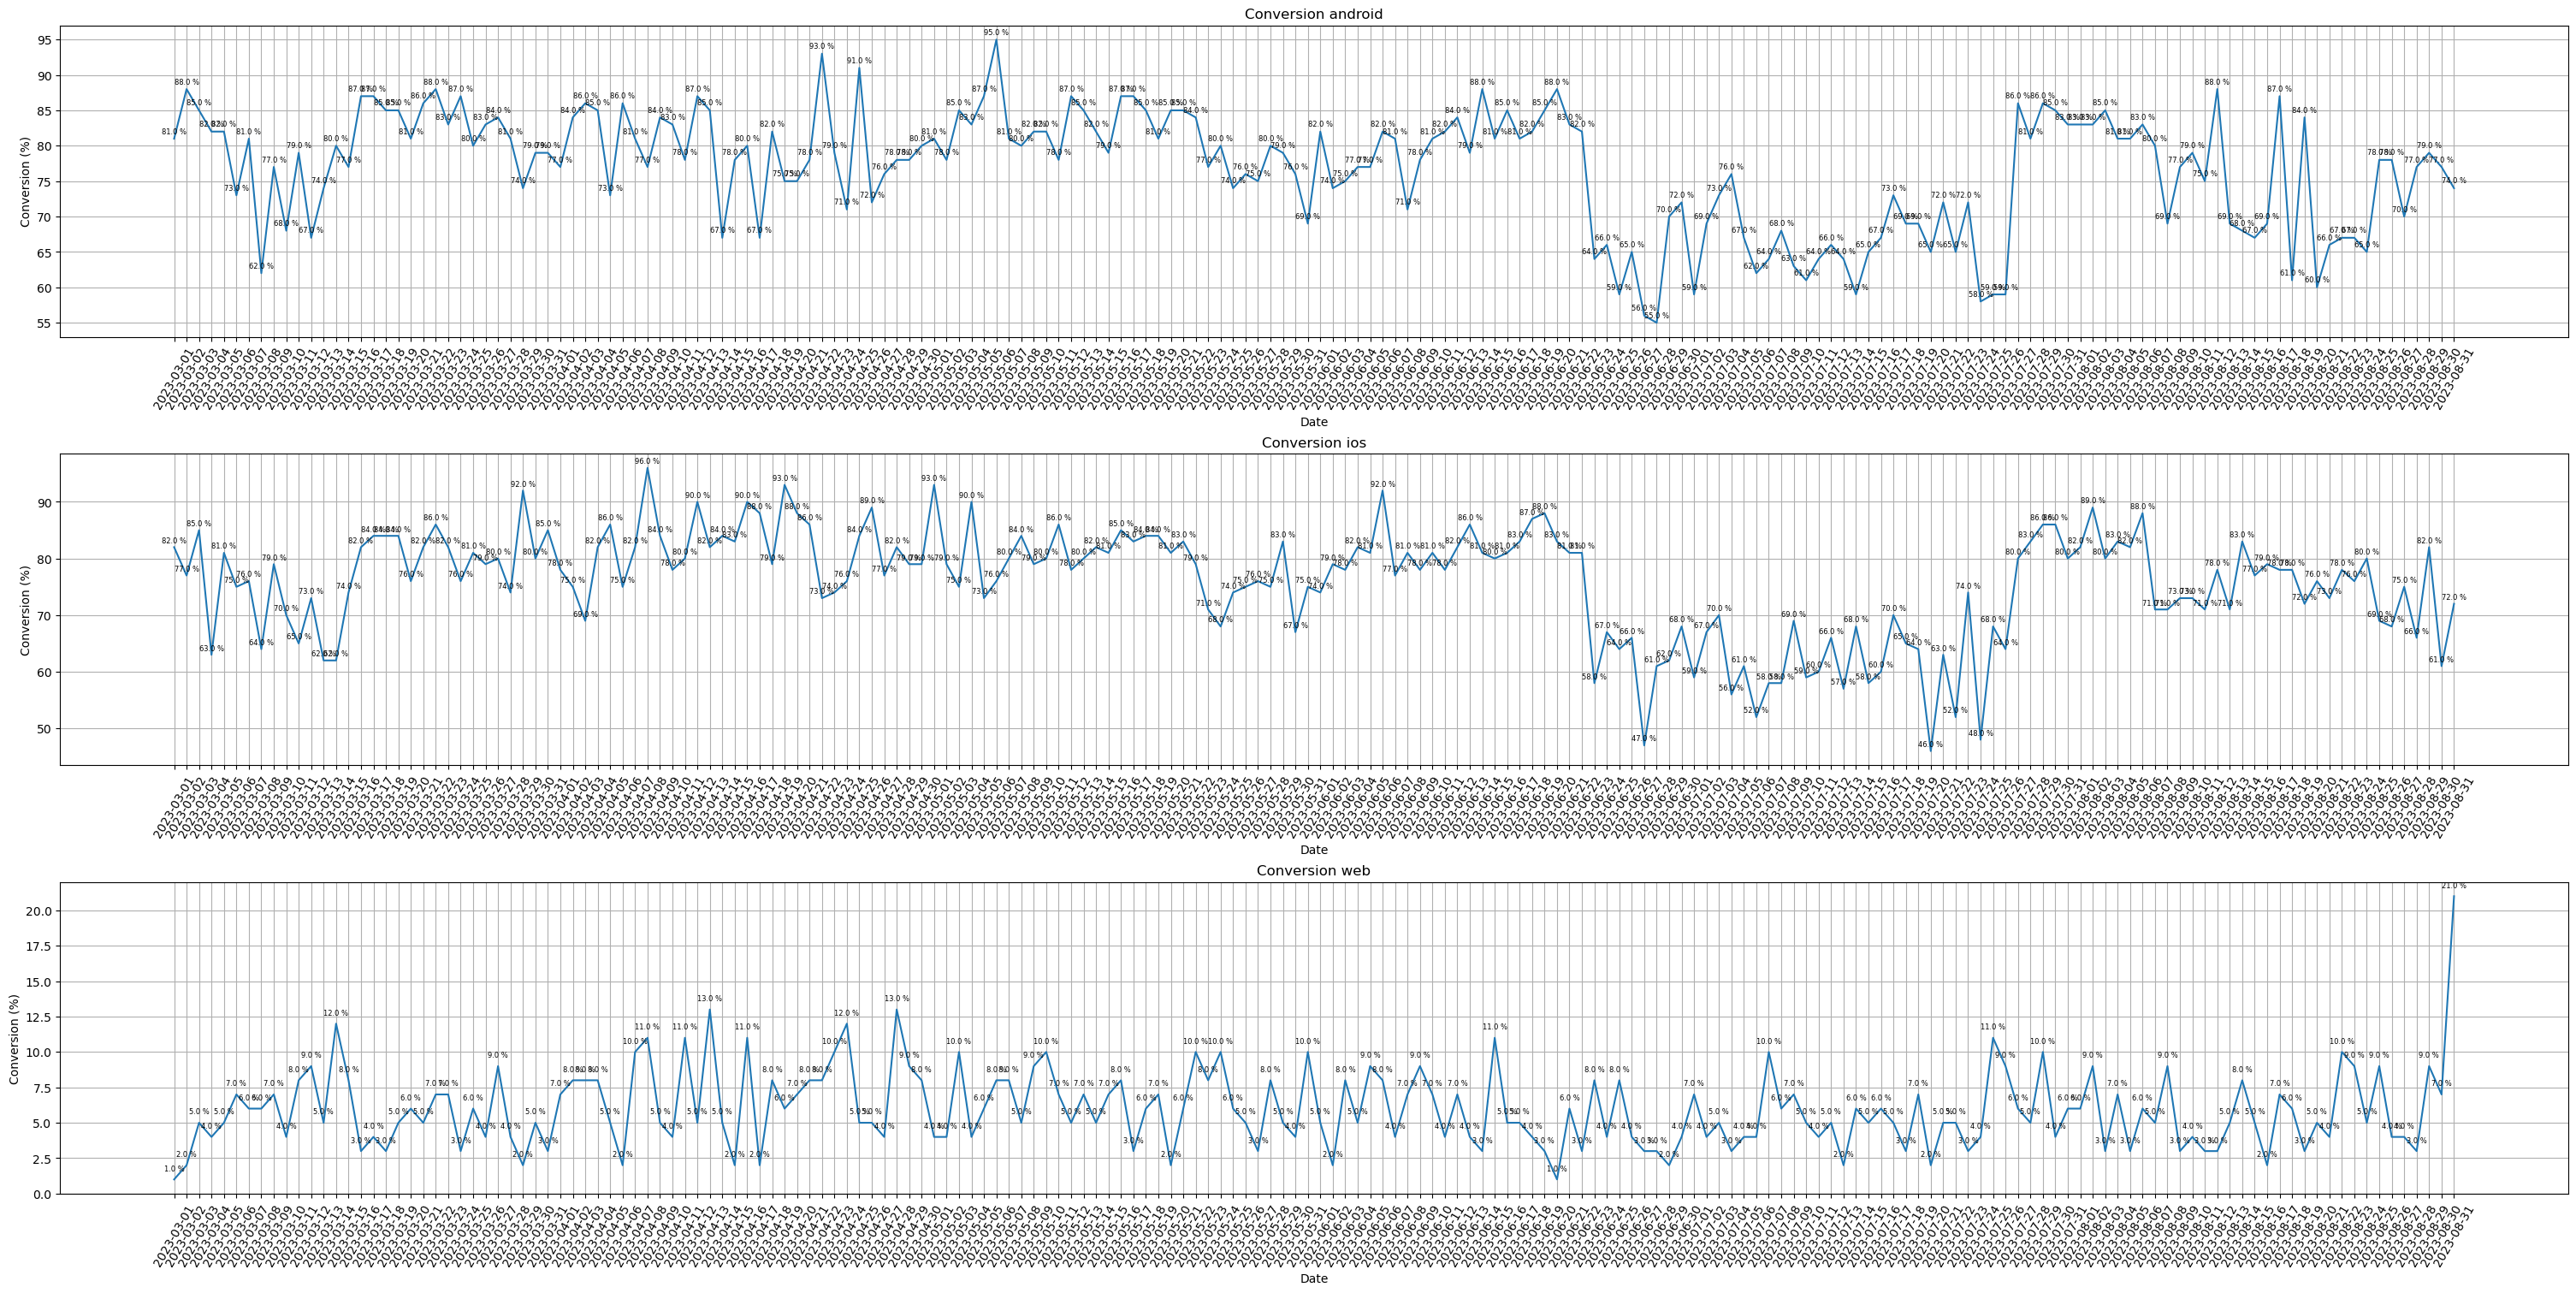

In [ ]:
conversion_android = conversion[conversion["platform"] == "android"]
conversion_ios = conversion[conversion["platform"] == "ios"]
conversion_web = conversion[conversion["platform"] == "web"]

fig, axes = plt.subplots(3, 1, constrained_layout=True)
fig.set_size_inches(30, 15)

axes[0].plot("date_group", "conversion", data=conversion_android)
axes[0].set_title("Conversion android")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Conversion (%)")
axes[0].xaxis.set_tick_params(rotation=60)
axes[0].grid()
for x, y in zip(conversion_android["date_group"], conversion_android["conversion"]):
    axes[0].text(x, y + 0.5, f'{y} %', ha='center', va='bottom', fontsize=6)

axes[1].plot("date_group", "conversion", data=conversion_ios)
axes[1].set_title("Conversion ios")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Conversion (%)")
axes[1].xaxis.set_tick_params(rotation=60)
axes[1].grid()
for x, y in zip(conversion_ios["date_group"], conversion_ios["conversion"]):
    axes[1].text(x, y + 0.5, f'{y} %', ha='center', va='bottom', fontsize=6)

axes[2].plot("date_group", "conversion", data=conversion_web)
axes[2].set_title("Conversion web")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Conversion (%)")
axes[2].xaxis.set_tick_params(rotation=60)
axes[2].grid()
for x, y in zip(conversion_web["date_group"], conversion_web["conversion"]):
    axes[2].text(x, y + 0.5, f'{y} %', ha='center', va='bottom', fontsize=6)

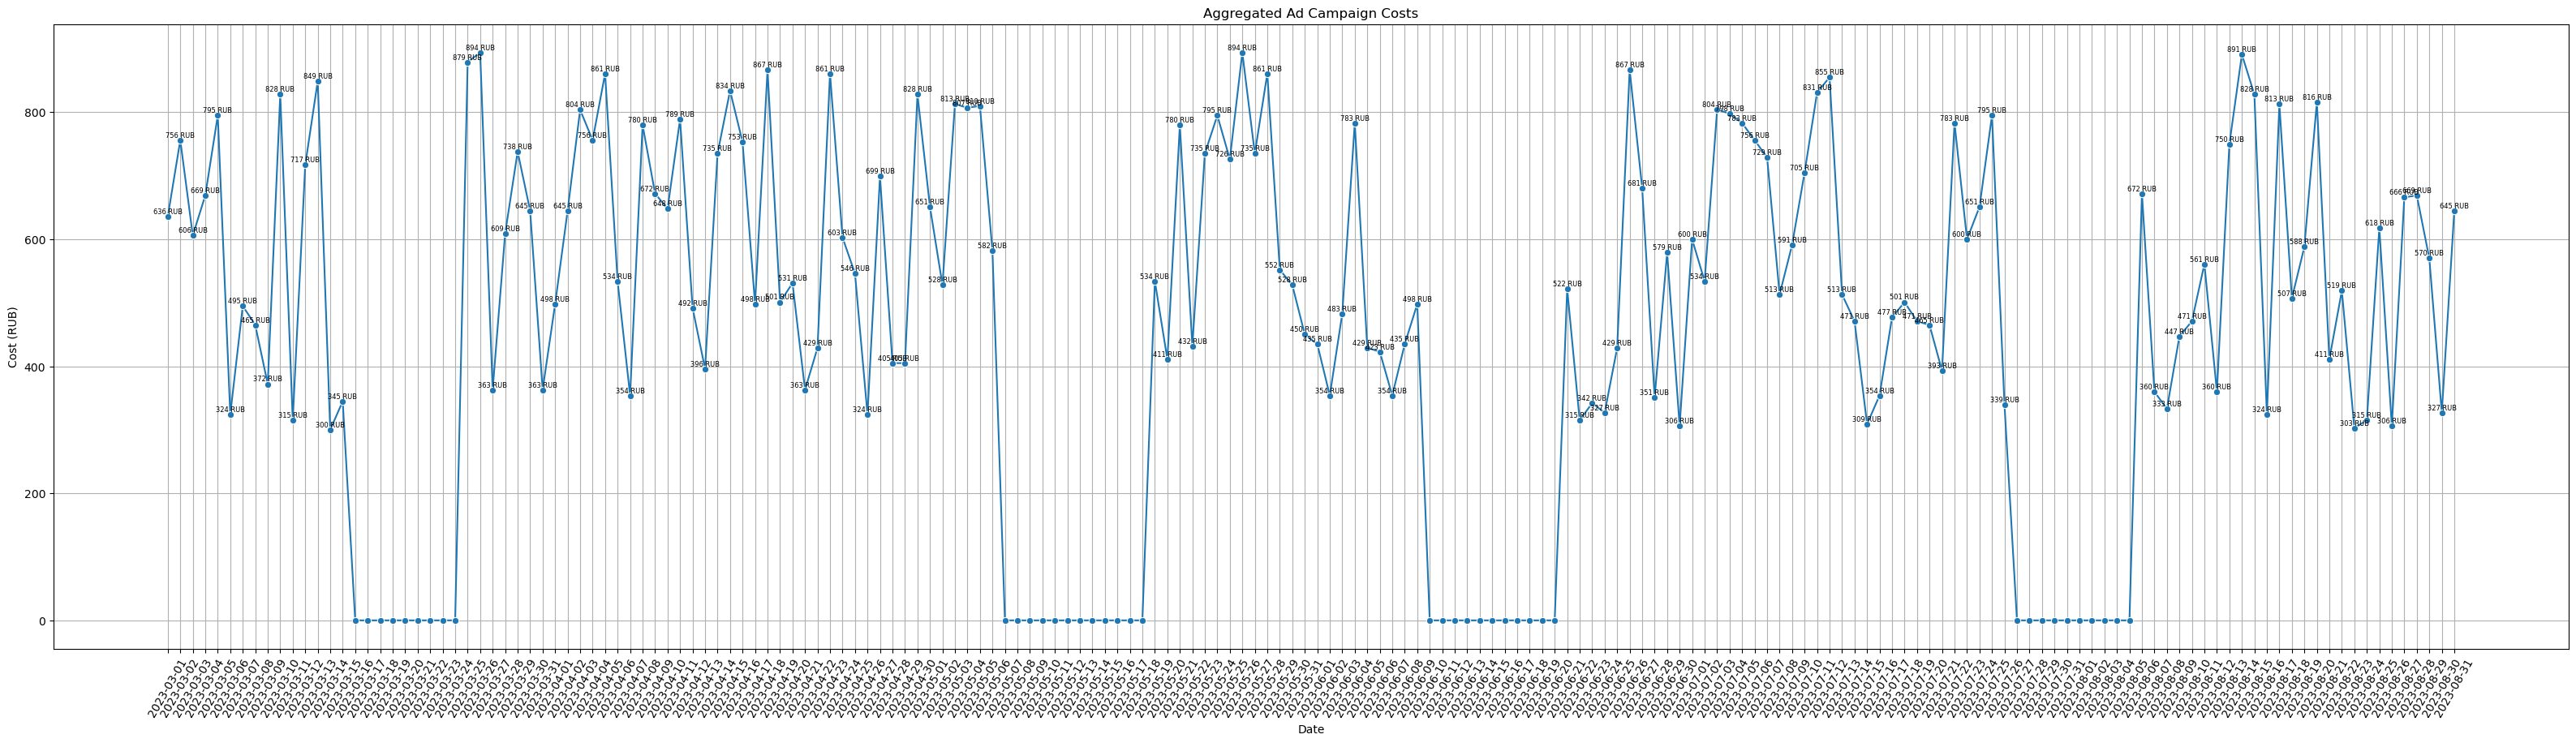

In [220]:
fig, ax = plt.subplots(figsize=(40, 10))
sns.lineplot(data=conversion_and_ads, x="date_group", y="cost", marker="o").set(title="Aggregated Ad Campaign Costs", xlabel="Date", ylabel="Cost (RUB)")
ax.xaxis.set_tick_params(rotation=60)
plt.grid()
for x, y in zip(conversion_and_ads["date_group"], conversion_and_ads["cost"]):
    if y != 0:
        ax.text(x, y + 2, f'{y} RUB', ha='center', va='bottom', fontsize=6)

(0.0, 250.0)

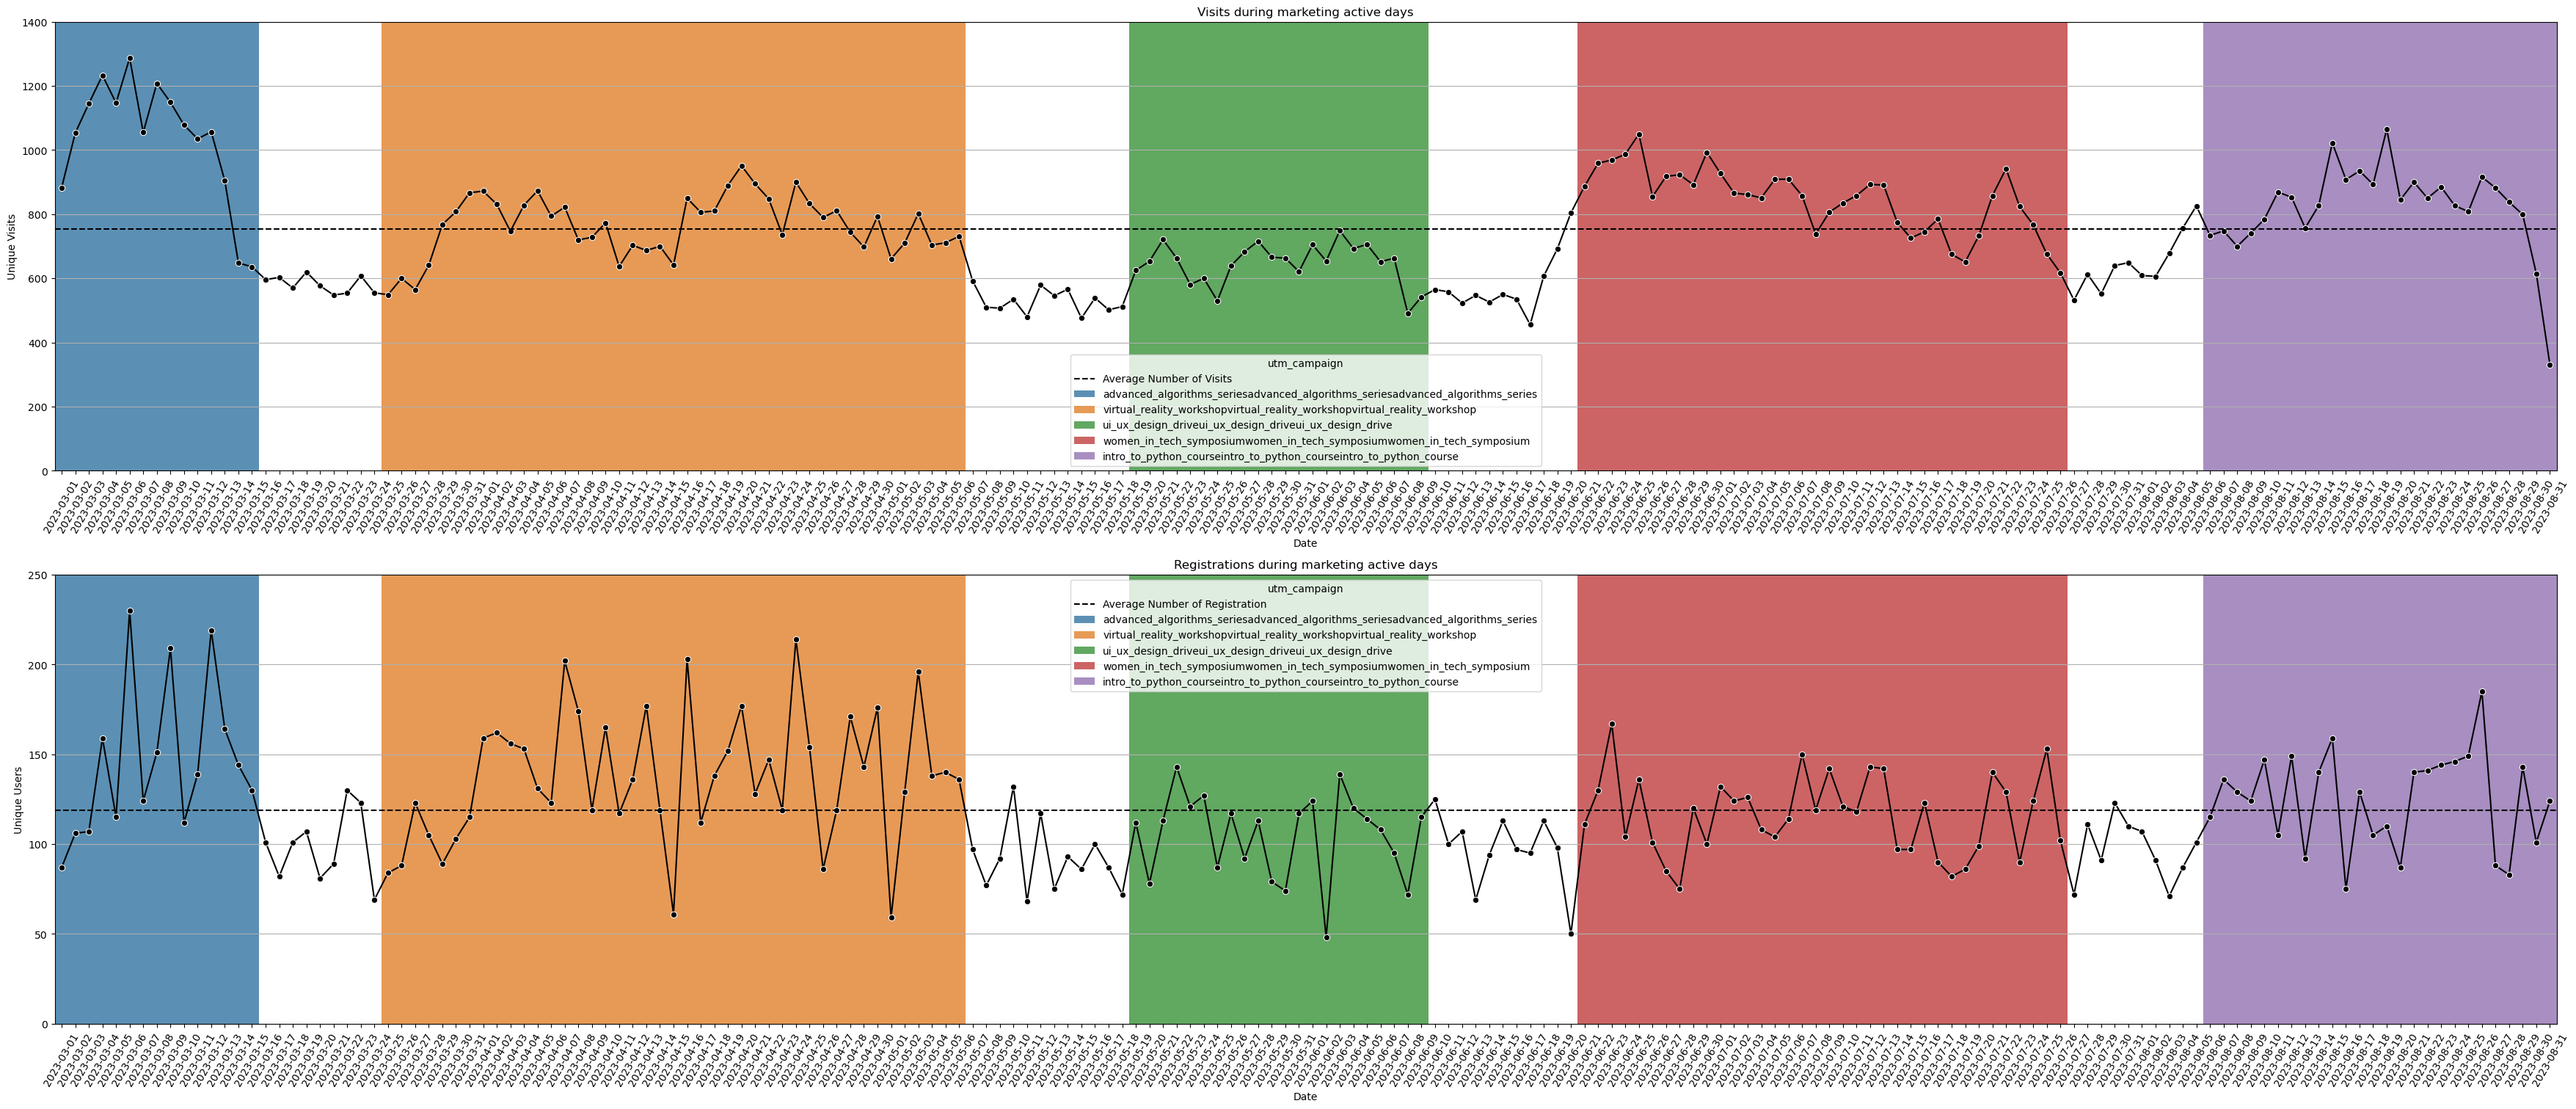

In [217]:
without_none = conversion_and_ads[conversion_and_ads["utm_campaign"] != "none"]

fig, axes = plt.subplots(2, 1, constrained_layout=True)
fig.set_size_inches(35, 15)

sns.lineplot(data=conversion_and_ads, x="date_group", y="visits", marker="o", color='black', ax=axes[0]).set(title="Visits during marketing active days", xlabel="Date", ylabel="Unique Visits")
axes[0].xaxis.set_tick_params(rotation=60)
axes[0].grid()
axes[0].axhline(conversion_and_ads["visits"].mean(), color='black', linestyle='--', label="Average Number of Visits")
axes[0].legend()
sns.barplot(data=conversion_and_ads,y=1400, x="date_group", hue=without_none["utm_campaign"], alpha=0.8, width=1, dodge=False, ax=axes[0])
axes[0].set_ylim(0, 1400)

sns.lineplot(data=conversion_and_ads, x="date_group", y="registrations", marker="o", color='black', ax=axes[1]).set(title="Registrations during marketing active days", xlabel="Date", ylabel="Unique Users")
axes[1].xaxis.set_tick_params(rotation=60)
axes[1].grid()
axes[1].axhline(conversion_and_ads["registrations"].mean(), color='black', linestyle='--', label="Average Number of Registration")
axes[1].legend()
sns.barplot(data=conversion_and_ads,y=250, x="date_group", hue=without_none["utm_campaign"], alpha=0.8, width=1, dodge=False, ax=axes[1])
axes[1].set_ylim(0, 250)